# ML Algorithms From Scratch — Visual Walkthrough

This notebook visually demonstrates the algorithms implemented in this repository:
decision boundaries for classifiers, cluster assignments for unsupervised methods,
training loss curves, and dimensionality reduction plots — all using **only the
from-scratch implementations in this repo**, no scikit-learn models.

Run top to bottom, or just browse the rendered output on GitHub.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

from regression.linear_regression import LinearRegression
from classification.logistic_regression import LogisticRegression
from classification.knn import KNN
from classification.decision_tree import DecisionTree
from classification.naive_bayes import GaussianNaiveBayes
from classification.svm import SVM
from clustering.kmeans import KMeans
from clustering.hierarchical_clustering import AgglomerativeClustering
from clustering.dbscan import DBSCAN
from clustering.gaussian_mixture import GaussianMixture
from dimensionality_reduction.pca import PCA
from ensemble.random_forest import RandomForest
from neural_network.mlp import MLP

def decision_boundary_data(seed=0, n=100):
    rng = np.random.RandomState(seed)
    X0 = rng.randn(n, 2) * 0.9 + np.array([-2, -2])
    X1 = rng.randn(n, 2) * 0.9 + np.array([2, 2])
    X = np.vstack([X0, X1])
    y = np.array([0]*n + [1]*n)
    return X, y

def plot_decision_boundary(model, X, y, title, predict_fn=None, ax=None):
    predict_fn = predict_fn or model.predict
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_fn(grid)
    Z = np.where(Z < 0, 0, Z)  # handle SVM's -1/+1 labels
    Z = Z.reshape(xx.shape)

    if ax is None:
        fig, ax = plt.subplots()
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k', s=25)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

## 1. Classifier Decision Boundaries

Each model draws a different kind of boundary between the two classes — smooth and linear for Logistic Regression and SVM, jagged and axis-aligned for the Decision Tree, blocky for KNN.

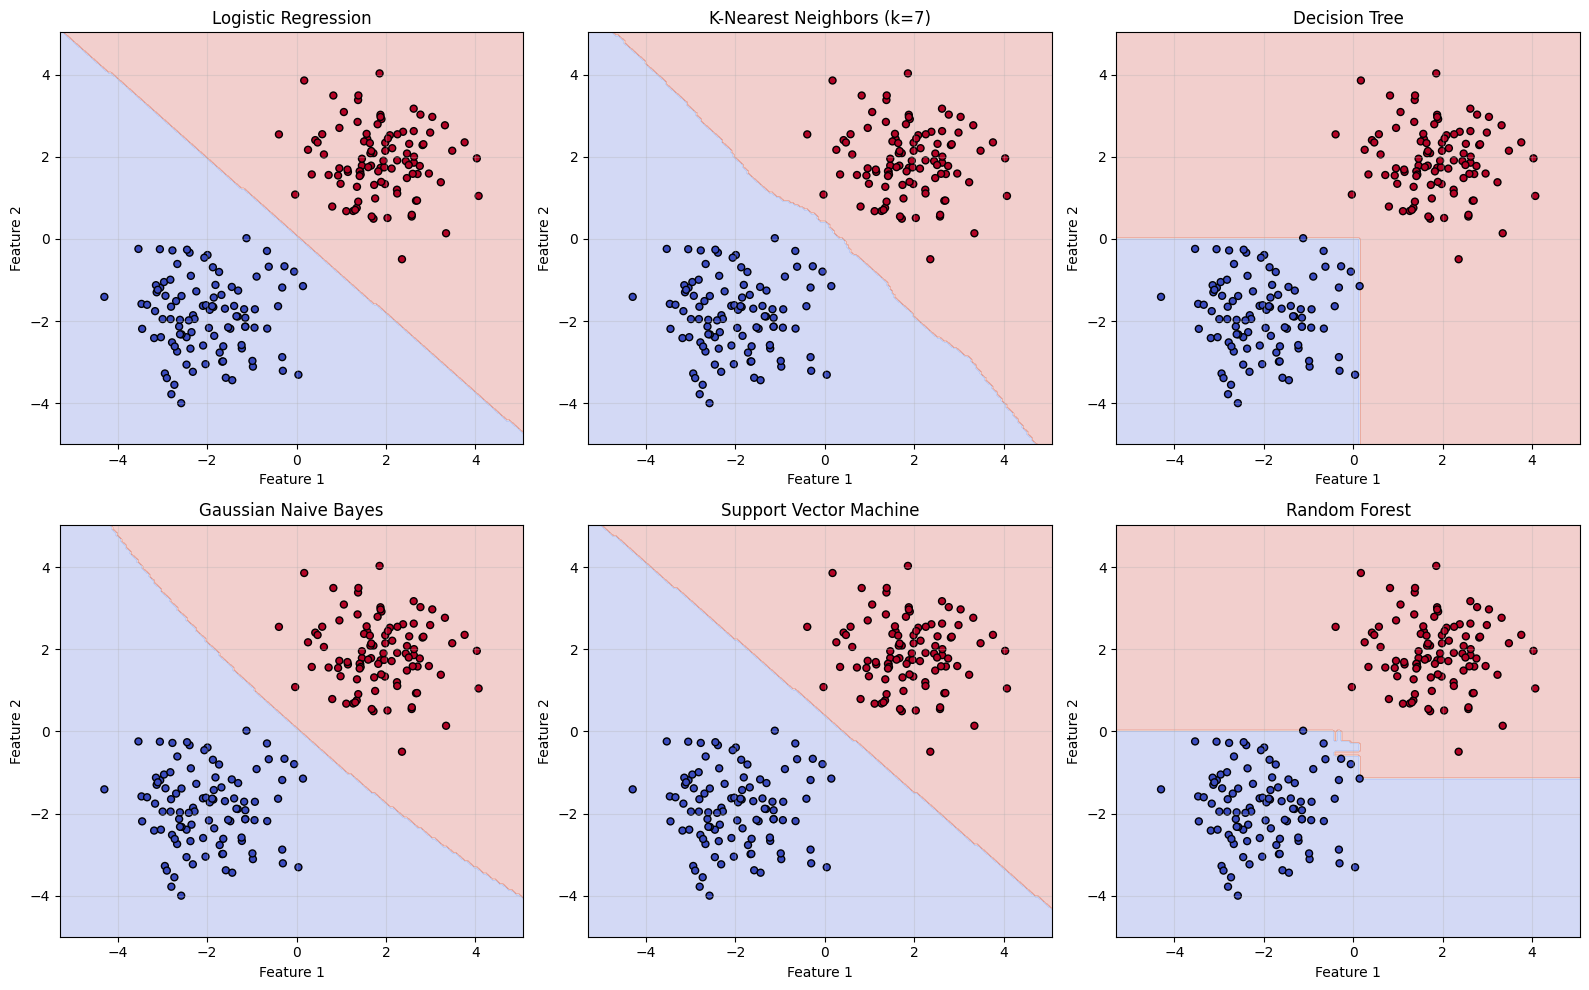

In [2]:
X, y = decision_boundary_data()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

models = [
    (LogisticRegression(learning_rate=0.1, n_iters=1000), "Logistic Regression"),
    (KNN(k=7), "K-Nearest Neighbors (k=7)"),
    (DecisionTree(max_depth=5), "Decision Tree"),
    (GaussianNaiveBayes(), "Gaussian Naive Bayes"),
    (SVM(n_iters=500), "Support Vector Machine"),
    (RandomForest(n_trees=15, max_depth=6), "Random Forest"),
]

for ax, (model, name) in zip(axes.ravel(), models):
    model.fit(X, y)
    plot_decision_boundary(model, X, y, name, ax=ax)

plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=100, bbox_inches='tight')
plt.show()

## 2. Linear Regression — Fit & Loss Curve

Gradient descent fits a line to noisy data. The loss curve shows MSE dropping over iterations as the model converges.

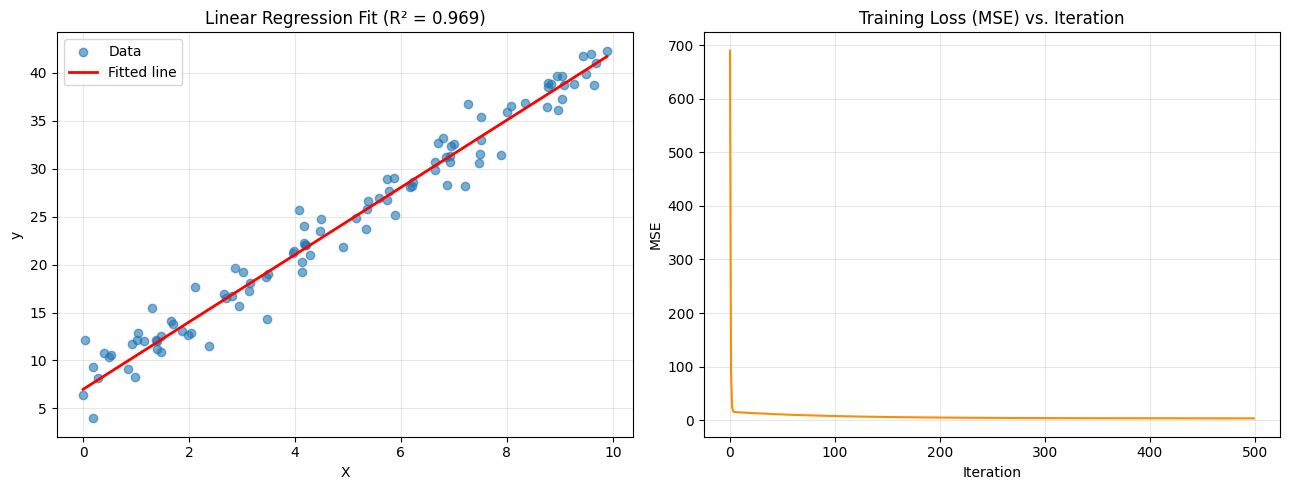

In [3]:
rng = np.random.RandomState(1)
X_reg = rng.rand(100, 1) * 10
y_reg = 3.5 * X_reg.squeeze() + 7 + rng.randn(100) * 2

model = LinearRegression(learning_rate=0.01, n_iters=500)
model.fit(X_reg, y_reg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_reg, y_reg, alpha=0.6, label='Data')
x_line = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
axes[0].plot(x_line, model.predict(x_line), color='red', linewidth=2, label='Fitted line')
axes[0].set_title(f'Linear Regression Fit (R² = {model.score(X_reg, y_reg):.3f})')
axes[0].set_xlabel('X'); axes[0].set_ylabel('y'); axes[0].legend()

axes[1].plot(model.loss_history, color='darkorange')
axes[1].set_title('Training Loss (MSE) vs. Iteration')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('MSE')

plt.tight_layout()
plt.savefig('linear_regression.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Neural Network — Decision Boundary & Loss Curve

A 3-class MLP trained with manual backpropagation. Note the smoother, more flexible boundary compared to the linear models above.

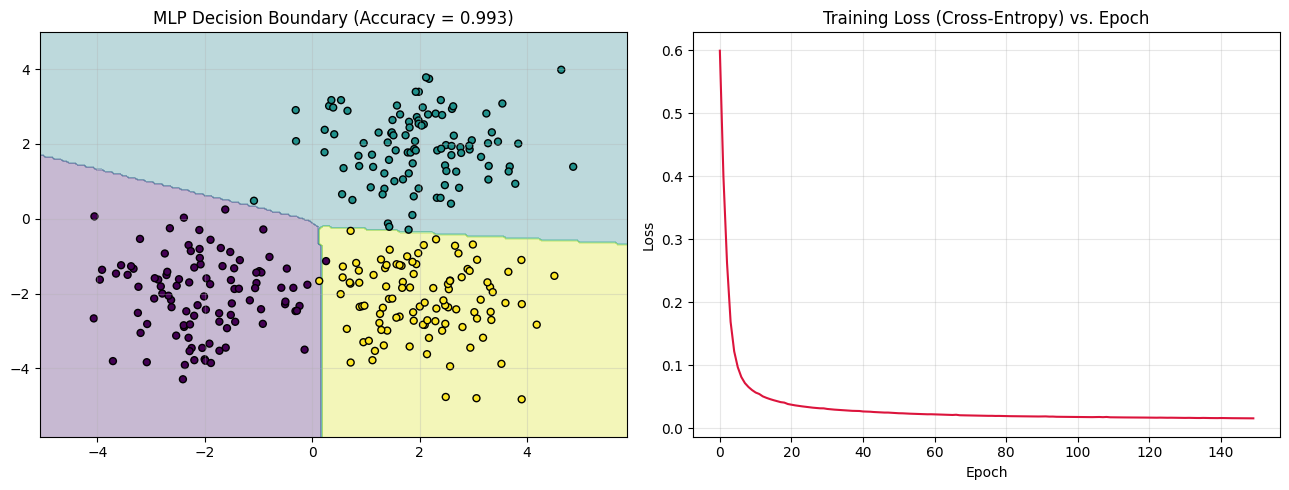

In [4]:
rng = np.random.RandomState(7)
X0 = rng.randn(100, 2) + np.array([-2, -2])
X1 = rng.randn(100, 2) + np.array([2, 2])
X2 = rng.randn(100, 2) + np.array([2, -2])
X_multi = np.vstack([X0, X1, X2])
y_multi = np.array([0]*100 + [1]*100 + [2]*100)

mlp = MLP(layer_sizes=[2, 16, 8, 3], learning_rate=0.05, n_epochs=150)
mlp.fit(X_multi, y_multi)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_min, x_max = X_multi[:,0].min()-1, X_multi[:,0].max()+1
y_min, y_max = X_multi[:,1].min()-1, X_multi[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
axes[0].scatter(X_multi[:,0], X_multi[:,1], c=y_multi, cmap='viridis', edgecolor='k', s=25)
axes[0].set_title(f'MLP Decision Boundary (Accuracy = {mlp.score(X_multi, y_multi):.3f})')

axes[1].plot(mlp.loss_history, color='crimson')
axes[1].set_title('Training Loss (Cross-Entropy) vs. Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.savefig('neural_network.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Clustering Algorithms Compared

Four different unsupervised approaches to grouping the same data: centroid-based (K-Means), bottom-up merging (Hierarchical), density-based (DBSCAN, which also detects noise/outliers), and probabilistic (Gaussian Mixture).

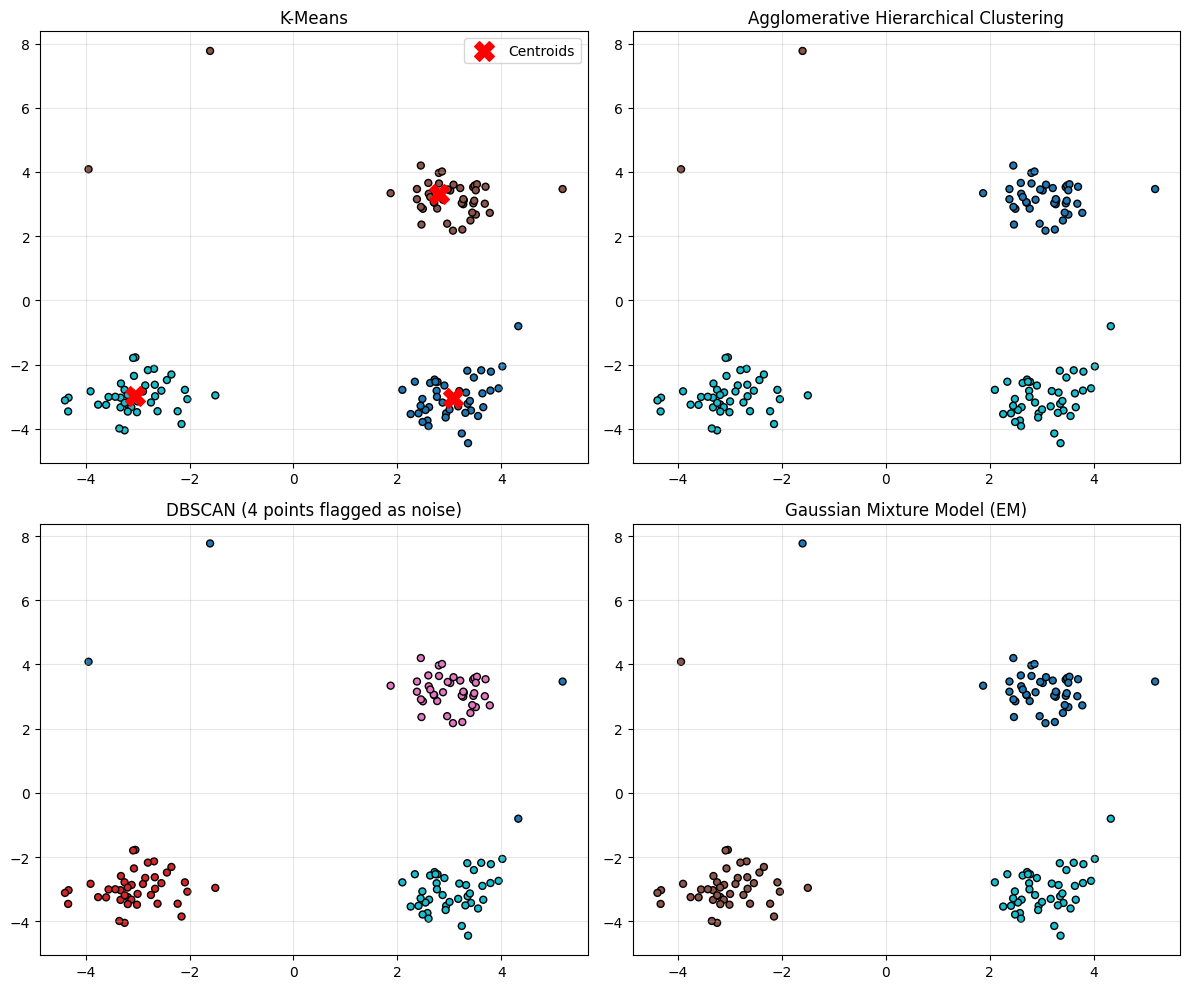

In [5]:
rng = np.random.RandomState(9)
X0 = rng.randn(40, 2) * 0.5 + np.array([-3, -3])
X1 = rng.randn(40, 2) * 0.5 + np.array([3, 3])
X2 = rng.randn(40, 2) * 0.5 + np.array([3, -3])
noise = rng.uniform(-8, 8, size=(6, 2))
X_clust = np.vstack([X0, X1, X2, noise])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

km = KMeans(k=3, random_state=42).fit(X_clust)
axes[0,0].scatter(X_clust[:,0], X_clust[:,1], c=km.labels_, cmap='tab10', edgecolor='k', s=25)
axes[0,0].scatter(km.centroids[:,0], km.centroids[:,1], c='red', marker='X', s=200, label='Centroids')
axes[0,0].set_title('K-Means'); axes[0,0].legend()

agg = AgglomerativeClustering(n_clusters=3, linkage='average')
labels_agg = agg.fit_predict(X_clust)
axes[0,1].scatter(X_clust[:,0], X_clust[:,1], c=labels_agg, cmap='tab10', edgecolor='k', s=25)
axes[0,1].set_title('Agglomerative Hierarchical Clustering')

db = DBSCAN(eps=1.0, min_samples=5)
labels_db = db.fit_predict(X_clust)
axes[1,0].scatter(X_clust[:,0], X_clust[:,1], c=labels_db, cmap='tab10', edgecolor='k', s=25)
n_noise = np.sum(labels_db == -1)
axes[1,0].set_title(f'DBSCAN ({n_noise} points flagged as noise)')

gmm = GaussianMixture(n_components=3).fit(X_clust)
labels_gmm = gmm.predict(X_clust)
axes[1,1].scatter(X_clust[:,0], X_clust[:,1], c=labels_gmm, cmap='tab10', edgecolor='k', s=25)
axes[1,1].set_title('Gaussian Mixture Model (EM)')

plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. PCA — Dimensionality Reduction

Reducing 5 correlated features down to 2 principal components, and checking how much variance each component captures.

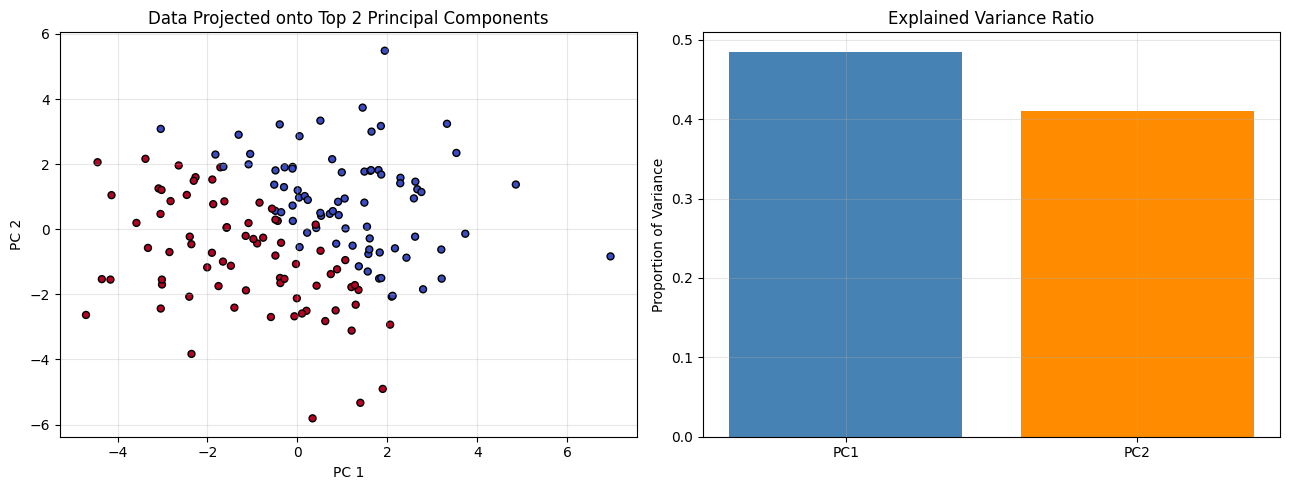

Total variance explained by 2 components: 89.55%


In [6]:
rng = np.random.RandomState(6)
X_5d = rng.randn(150, 5)
X_5d[:, 1] = X_5d[:, 0] * 1.8 + rng.randn(150) * 0.2   # correlated with feature 0
X_5d[:, 3] = X_5d[:, 2] * -1.5 + rng.randn(150) * 0.3  # correlated with feature 2
labels_5d = (X_5d[:, 0] + X_5d[:, 2] > 0).astype(int)  # just for coloring

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_5d)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_reduced[:,0], X_reduced[:,1], c=labels_5d, cmap='coolwarm', edgecolor='k', s=25)
axes[0].set_title('Data Projected onto Top 2 Principal Components')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')

axes[1].bar(['PC1', 'PC2'], pca.explained_variance_ratio_, color=['steelblue', 'darkorange'])
axes[1].set_title('Explained Variance Ratio')
axes[1].set_ylabel('Proportion of Variance')

plt.tight_layout()
plt.savefig('pca.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

## Summary

| Algorithm | What the plot shows |
|---|---|
| Logistic Regression / SVM | Linear, smooth decision boundaries |
| KNN / Decision Tree / Random Forest | Non-linear, locally-adaptive boundaries |
| Naive Bayes | Boundary shaped by per-class Gaussian assumptions |
| Linear Regression | Convergence of gradient descent via the loss curve |
| Neural Network (MLP) | Flexible, curved decision boundary + cross-entropy convergence |
| K-Means / Hierarchical / DBSCAN / GMM | Different philosophies for grouping unlabeled data |
| PCA | Compressing correlated features into fewer informative dimensions |

All models are implemented from scratch in this repository — see the individual `.py` files for the underlying math and code.